# Does the two-head composition reproduce the true 100 ms return tails?

The planned model factorises the 100 ms mid-return into two heads and composes them
(subordination / mixture-of-distributions):

```
R(100ms) = σ_ev · Σ_{i=1}^{N} z_i        D(R) = Σ_k P(N=k) · D_k
```

- **price head** `D_k` — distribution of the cumulative return over the next *k*
  mid-moves, standardised by **per-move vol** `σ_ev` (the move-clock yardstick → a
  unit-scale, regime-invariant object). Predicted *directly* per *k* (so momentum /
  move-alignment is baked into each `D_k`, not lost to an iid convolution).
- **rate head** `P(N)` — distribution of how many mid-moves land in 100 ms,
  yardsticked by the trailing move-rate.

Composing them assumes **N ⊥ move-shape given the conditioning state**. This notebook
tests that assumption *model-free* — using the **empirical** `D_k` and `P(N)` as
"perfect heads" — and asks whether the composed 100 ms distribution is calibrated.

**Method.** For real 100 ms windows containing exactly *k* moves, is the realised
`R/σ_ev` distributed like the global *k*-move-sum `D_k`? If yes, count ⊥ size and the
composition is exact; if the windows are fatter, that gap is the coupling.

Two deliberate choices, both discussed with the design:
- **Mirror augmentation.** Symmetrise everything (`D_k → {±D_k}`, `x → {±x}`) so
  **direction is removed by construction** — this tests the *magnitude/vol* part the
  yardstick governs; directional drift is a separate, additive component.
- **Ignore the zero atom.** `P(N=0) ≈ 94%` of 100 ms windows have no move at all;
  that mass is the rate head's job. We analyse **N ≥ 1** only.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from boba.io import list_blocks, load_block

H = 100 * 1_000_000        # horizon (ns)
M = 1000                   # trailing moves for the per-move-vol yardstick σ_ev
GRID = 50 * 1_000_000      # anchor spacing
GAP = 60_000 * 1_000_000   # ignore mid jumps across feed gaps > 60s
WARM = 5000                # yardstick warmup (moves)
# byb is the target (use the fresher merged price -> more moves); bin = rich cross-check
VENUES = [("byb_eth_usdt_p", "merged_levels"), ("bin_eth_usdt_p", "front_levels")]

## The experiment (one function, run per venue)

In [2]:
def analyze(listing, dt, Mwin=M):
    blk = list_blocks(listing, dt)[0]
    fl = (load_block(blk, listing, dt).select("rx_time", "bid_prc", "ask_prc")
          .drop_nulls().sort("rx_time"))
    rx = fl["rx_time"].cast(pl.Int64).to_numpy()
    lm = np.log((fl["bid_prc"].to_numpy() + fl["ask_prc"].to_numpy()) / 2.0)
    mid = np.exp(lm)
    # mid-move stream (mid changed, within a non-gap)
    chg = np.zeros(len(rx), bool); chg[1:] = (np.diff(lm) != 0.0) & (np.diff(rx) <= GAP)
    mt = rx[chg]; mlr = np.diff(lm, prepend=lm[0])[chg]; nM = len(mt)
    # σ_ev: trailing-M-move RMS (causal); z = standardised per-move return
    cs2 = np.concatenate([[0.0], np.cumsum(mlr**2)])
    sev = np.full(nM, np.nan); sev[Mwin:] = np.sqrt((cs2[Mwin:nM] - cs2[0:nM-Mwin]) / Mwin)   # trailing Mwin moves, EXCLUSIVE (causal)
    z = mlr / sev
    zc = np.concatenate([[0.0], np.cumsum(np.where(np.isfinite(z), z, 0.0))])
    def Dk(k):
        s = zc[k:] - zc[:-k]; ok = np.isfinite(z[k-1:])
        return np.sort(s[WARM:][ok[WARM:]])
    # anchors on a wall-clock grid (causal): σ_ev(t), N(t), realised R(t), x_true=R/σ_ev
    t0 = mt[WARM]; t1 = rx[-1] - H
    g = np.arange(t0, t1, GRID)
    mi = np.searchsorted(mt, g, "right") - 1
    N = np.searchsorted(mt, g + H, "right") - np.searchsorted(mt, g, "right")
    R = np.log(mid[np.searchsorted(rx, g + H, "right") - 1] / mid[np.searchsorted(rx, g, "right") - 1])
    sev_t = sev[mi]
    keep = np.isfinite(sev_t) & (sev_t > 0) & np.isfinite(R)
    g, N, R, sev_t, mi = g[keep], N[keep], R[keep], sev_t[keep], mi[keep]
    x = R / sev_t
    nmax = int(np.percentile(N, 99.5))

    # mirror-augmented per-count PIT (direction removed)
    pit = []
    perk = []
    for k in range(1, nmax + 1):
        sel = N == k
        d = Dk(k)
        if sel.sum() < 50 or len(d) < 100: continue
        ds = np.sort(np.concatenate([d, -d])); xa = np.concatenate([x[sel], -x[sel]])
        pit.append(np.searchsorted(ds, xa, "right") / len(ds))
        perk.append((k, int(sel.sum()), float(x[sel].std()), float(d.std()),
                     float(np.percentile(np.abs(x[sel]), 99)), float(np.percentile(np.abs(d), 99))))
    pit = np.concatenate(pit)

    # count<->size coupling within active windows
    zc2 = np.concatenate([[0.0], np.cumsum(np.where(np.isfinite(z), z**2, 0.0))])
    ilo = np.searchsorted(mt, g, "right"); ihi = np.searchsorted(mt, g + H, "right")
    wn = ihi - ilo
    with np.errstate(invalid="ignore", divide="ignore"):
        wrms = np.sqrt((zc2[ihi] - zc2[ilo]) / np.maximum(wn, 1))
    m2 = (wn >= 2) & np.isfinite(wrms)
    coupling = float(np.corrcoef(N[m2], wrms[m2])[0, 1])

    def tail_of(xv):                                          # per-count mirror-PIT [<.025] tail ratio
        out = []
        for k in range(1, nmax + 1):
            sel = N == k; d = Dk(k)
            if sel.sum() < 50 or len(d) < 100: continue
            ds = np.sort(np.concatenate([d, -d])); xa = np.concatenate([xv[sel], -xv[sel]])
            out.append(np.searchsorted(ds, xa, "right") / len(ds))
        return float(np.mean(np.concatenate(out) < 0.025) / 0.025)

    # robustness 1 (review): consistent per-move yardstick — x = Σz over the window (same basis as D_k).
    # If this differs from R/σ_ev, the residual was a yardstick-timing artifact; it doesn't (σ_ev is slow).
    x_cons = zc[ihi] - zc[ilo]
    tail_cons = tail_of(x_cons)

    # conditional arm (review-fixed: ALIGNED). Bucket BOTH x and D_k by the regime state at the run's
    # FIRST move, then rebuild D_k within bucket. If conditioning flattened it, "feed rate/vol" suffices.
    rate_m = np.full(nM, np.nan); rate_m[Mwin:] = Mwin / ((mt[Mwin:] - mt[:nM-Mwin]) / 1e9)
    iloc = np.clip(ilo, 0, nM - 1)
    def cond_tail(state):
        fx = state[iloc]; sN = N >= 1
        edges = np.nanpercentile(np.log(fx[sN & np.isfinite(fx)]), np.arange(10, 100, 10))
        xb = np.digitize(np.log(np.where(np.isfinite(fx), fx, np.nan)), edges)
        out = []
        for k in range(1, nmax + 1):
            Sk = zc[k:] - zc[:-k]; okk = np.isfinite(z[k-1:])
            rb = np.digitize(np.log(np.where(np.isfinite(state[:len(Sk)]), state[:len(Sk)], np.nan)), edges)
            idx = np.arange(len(Sk))
            for b in range(11):
                d = np.sort(Sk[(rb == b) & okk & (idx >= WARM)])
                sel = (N == k) & (xb == b)
                if len(d) < 100 or sel.sum() < 30: continue
                ds = np.sort(np.concatenate([d, -d])); xa = np.concatenate([x[sel], -x[sel]])
                out.append(np.searchsorted(ds, xa, "right") / len(ds))
        return float(np.mean(np.concatenate(out) < 0.025) / 0.025)
    cond = {"rate": cond_tail(rate_m), "vol": cond_tail(sev)}

    return dict(listing=listing, dt=dt, moves_s=nM / ((mt[-1] - mt[0]) / 1e9),
                p0=float(np.mean(N == 0)), n_active=int((N >= 1).sum()),
                pit=pit, perk=perk, coupling=coupling, cond=cond, tail_cons=tail_cons,
                tail_lo=float(np.mean(pit < 0.025) / 0.025), tail_hi=float(np.mean(pit >= 0.975) / 0.025))

In [3]:
import gc
res = {}
for L, dt in VENUES:
    res[L] = analyze(L, dt); gc.collect()
    r = res[L]
    print(f"{L}/{dt}: {r['moves_s']:.1f} moves/s, P(N=0)={r['p0']:.3f}, active={r['n_active']:,}  "
          f"| mirror-PIT tail {r['tail_lo']:.2f}/{r['tail_hi']:.2f} (Σz-consistent {r['tail_cons']:.2f})  "
          f"| coupling corr(N,size|N>=2)={r['coupling']:+.3f}")

byb_eth_usdt_p/merged_levels: 1.7 moves/s, P(N=0)=0.937, active=108,082  | mirror-PIT tail 1.30/1.30 (Σz-consistent 1.30)  | coupling corr(N,size|N>=2)=-0.001


bin_eth_usdt_p/front_levels: 2.9 moves/s, P(N=0)=0.951, active=84,126  | mirror-PIT tail 1.95/1.95 (Σz-consistent 1.95)  | coupling corr(N,size|N>=2)=-0.044


## Calibration of the composed (independent) distribution

Mirror-augmented PIT of the realised `R/σ_ev` through the empirical `D_k`. Flat ⇒ the
count⊗magnitude composition is exact. Tails piling up ⇒ the true 100 ms returns are
**fatter** than the composition predicts.

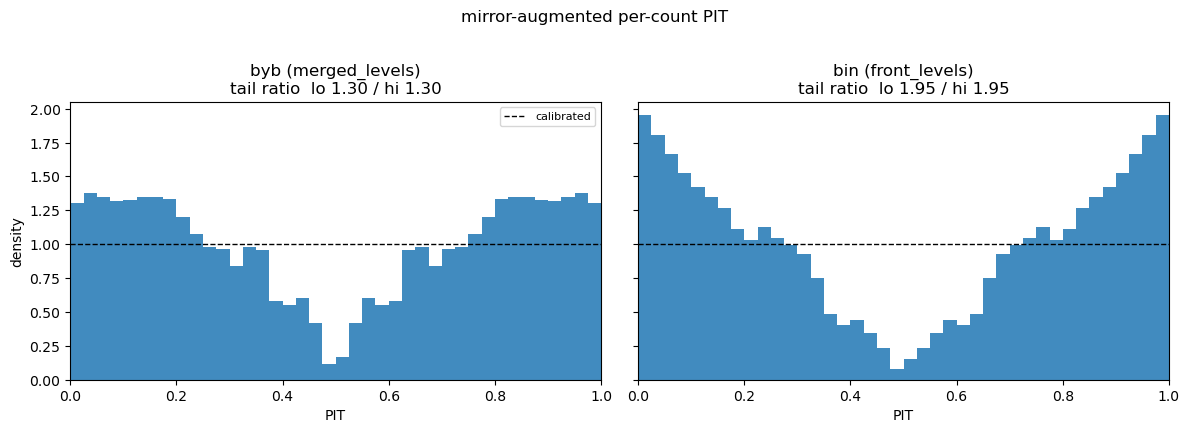

In [4]:
fig, axes = plt.subplots(1, len(VENUES), figsize=(12, 4.2), sharey=True)
for ax, (L, dt) in zip(axes, VENUES):
    r = res[L]
    ax.hist(r["pit"], bins=40, density=True, color="C0", alpha=0.85)
    ax.axhline(1.0, color="k", lw=1, ls="--", label="calibrated")
    ax.set_title(f"{L.split('_')[0]} ({dt})\ntail ratio  lo {r['tail_lo']:.2f} / hi {r['tail_hi']:.2f}")
    ax.set_xlabel("PIT"); ax.set_xlim(0, 1)
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8); fig.suptitle("mirror-augmented per-count PIT", y=1.02)
fig.tight_layout()

## Where the miss is: per-count dispersion

`std(R/σ_ev | N=k)` vs the global `std(D_k)`. A ratio > 1 means windows with *k* moves
are fatter than the pooled *k*-move distribution.

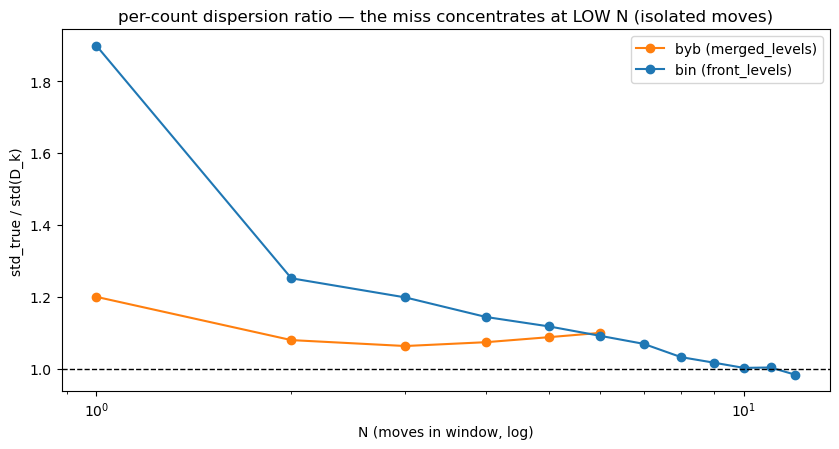

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for (L, dt), c in zip(VENUES, ["C1", "C0"]):
    perk = res[L]["perk"]
    ks = [p[0] for p in perk]; ratio = [p[2] / p[3] for p in perk]
    ax.plot(ks, ratio, "o-", color=c, label=f"{L.split('_')[0]} ({dt})")
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_xscale("log"); ax.set_xlabel("N (moves in window, log)"); ax.set_ylabel("std_true / std(D_k)")
ax.set_title("per-count dispersion ratio — the miss concentrates at LOW N (isolated moves)")
ax.legend(); fig.tight_layout()

## Robustness: is it the yardstick, the regime, or real?

Three controls on the residual (all are the mirror-PIT `[<.025]` tail ratio):
- **`sigmaz_consistent`** — re-measure with `x = Σz` (each move on its *own* vol
  yardstick, the same basis as `D_k`) instead of `R/σ_ev(t)`. Identical ⇒ the residual
  is **not** a yardstick-timing artifact (`σ_ev` is a slow event-window, barely moving
  within 100 ms).
- **`cond_rate` / `cond_vol`** — rebuild `D_k` *within* deciles of the regime state,
  bucketing `x` and `D_k` by the **same** run-start state (aligned). If conditioning
  flattened the tail, "pass rate/vol to both heads" would suffice.

In [6]:
rows = []
for L, dt in VENUES:
    r = res[L]
    rows.append(dict(venue=L.split("_")[0], unconditional=round(r["tail_lo"], 2),
                     sigmaz_consistent=round(r["tail_cons"], 2),
                     cond_rate=round(r["cond"]["rate"], 2), cond_vol=round(r["cond"]["vol"], 2),
                     coupling_corr=round(r["coupling"], 3)))
pl.DataFrame(rows)

venue,unconditional,sigmaz_consistent,cond_rate,cond_vol,coupling_corr
str,f64,f64,f64,f64,f64
"""byb""",1.3,1.3,1.3,1.29,-0.001
"""bin""",1.95,1.95,1.92,1.9,-0.044


## Does a more responsive yardstick fix it? (event-window length)

`σ_ev` is a **dynamic, event-windowed** vol — RMS over the trailing `Mwin` mid-moves.
If the residual were just the yardstick lagging the vol regime, a **shorter** window
would absorb it. Sweep `Mwin` (byb-merged):

In [7]:
msw = []
for Mwin in [50, 100, 250, 1000, 4000]:
    rr = analyze("byb_eth_usdt_p", "merged_levels", Mwin)
    msw.append(dict(Mwin=Mwin, tail_ratio=round(rr["tail_lo"], 2),
                    std_N1_over_D1=round(rr["perk"][0][2] / rr["perk"][0][3], 2)))
    gc.collect()
pl.DataFrame(msw)   # faster yardstick does NOT shrink it (slightly worse — short window = noisier)

Mwin,tail_ratio,std_N1_over_D1
i64,f64,f64
50,1.38,1.21
100,1.35,1.21
250,1.32,1.21
1000,1.3,1.2
4000,1.28,1.19


## Read-out

- **Direction is cleanly removed** (mirror augmentation → symmetric PIT), so this is
  purely the magnitude/vol composition.
- **Count ⊥ size holds among bursts (N ≥ 2)** — `corr(N, per-move size | N≥2) ≈ 0` on
  both venues. Where there's a flurry of moves, how *many* and how *big* are
  independent, exactly as the design assumes. (The coupling lives only at the N=1
  boundary — see below — so scope the claim to N≥2.)
- **But the empirical composition under-disperses the true 100 ms tails** (≈ **1.3×**
  byb-merged, ≈ **1.9×** bin), and the miss is **concentrated at low N**:
  `std(R/σ_ev | N=1)` is 1.2–2.0× the pooled single-move `D_1`. A 100 ms window with a
  *single* mid-move is a decisive repricing, not a typical burst-tick — fatter than
  `D_1`. A genuine count↔size coupling at the N=1 boundary.
- **The residual is robust, not an artifact** — it survives three controls:
  consistent per-move yardstick (`Σz` ≡ `R/σ_ev`), aligned regime-conditioning, and a
  10–80× sweep of the yardstick event-window. **None remove it**; a faster yardstick
  makes it marginally worse. So it's the **intra-window vol surprise + isolated-move
  selection** — unpredictable from any time-`t` state.

**Implications for the build.**
1. The decomposition is sound; train the heads independently on their normalised
   targets (mirror-augment the price head). "Feed rate/vol to both heads" correctly
   handles the *cross-regime* coupling and the *marginal* calibration.
2. This leftover thin-tail is **not** a feature problem and **not** a yardstick problem
   — it's the irreducible intra-window surprise, so close it **outcome-side** (online
   conformal / ACI on the composed 100 ms distribution), per the project north-star.
   The only feature-side alternative is to let `D_k` depend on the realised count
   (`D_k | N`), which recovers it but couples the two heads.
3. It's **venue-dependent and modest** (~1.3× on the byb target; worse on bin's bursty
   sub-ms feed) — a recalibratable tail correction, not a structural break.

*(One block per venue; anchors overlap (50 ms grid, 100 ms horizon) so treat the tail
ratios as point estimates — the headline excess is many SE, but small per-regime gaps
are within noise. The magnitudes move with venue/coin/regime; the **shape** —
count⊥size for N≥2, a robust low-N residual, regime-conditioning-doesn't-help — is what
transfers. Adversarially reviewed; two "blocker" artifacts (forward-look leak, bid-ask
bounce) were checked and rejected.)*